# 💎 Diamond Price Predictor
EDA → Preprocessing → Model → Değerlendirme

In [1]:
import os
print(os.getcwd())

/Users/senapoyraz/Desktop/diamonds_predictor


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

print("✅ Kütüphaneler yüklendi")

✅ Kütüphaneler yüklendi


In [3]:
df = pd.read_csv('data/diamonds.csv', index_col=0)

print(f"Satır: {df.shape[0]}, Sütun: {df.shape[1]}")
print("\n", df.head())
print("\nEksik değer:\n", df.isnull().sum())

Satır: 53940, Sütun: 10

    carat      cut color clarity  depth  table  price     x     y     z
1   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
2   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
3   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
4   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
5   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75

Eksik değer:
 carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


In [4]:
# Sıralı kategoriler (kötüden iyiye)
cut_order     = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order   = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

df['cut_enc']     = df['cut'].map({v: i for i, v in enumerate(cut_order)})
df['color_enc']   = df['color'].map({v: i for i, v in enumerate(color_order)})
df['clarity_enc'] = df['clarity'].map({v: i for i, v in enumerate(clarity_order)})

print(df[['cut', 'cut_enc', 'color', 'color_enc', 'clarity', 'clarity_enc']].head(8))

         cut  cut_enc color  color_enc clarity  clarity_enc
1      Ideal        4     E          5     SI2            1
2    Premium        3     E          5     SI1            2
3       Good        1     E          5     VS1            4
4    Premium        3     I          1     VS2            3
5       Good        1     J          0     SI2            1
6  Very Good        2     J          0    VVS2            5
7  Very Good        2     I          1    VVS1            6
8  Very Good        2     H          2     SI1            2


In [5]:
features = ['carat', 'cut_enc', 'color_enc', 'clarity_enc', 'depth', 'table', 'x', 'y', 'z']

X = df[features]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Eğitim seti : {X_train.shape[0]} satır")
print(f"Test seti   : {X_test.shape[0]} satır")
print(f"\nX örnek:\n{X_train.head(3)}")
print(f"\ny örnek:\n{y_train.head(3)}")

Eğitim seti : 43152 satır
Test seti   : 10788 satır

X örnek:
       carat  cut_enc  color_enc  clarity_enc  depth  table     x     y     z
26547   2.01        1          4            1   58.1   64.0  8.23  8.19  4.77
9160    1.01        2          5            1   60.0   60.0  6.57  6.49  3.92
14132   1.10        3          2            3   62.5   58.0  6.59  6.54  4.10

y örnek:
26547    16231
9160      4540
14132     5729
Name: price, dtype: int64


In [6]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Model eğitildi!")
print(f"Kullanılan özellikler: {features}")

✅ Model eğitildi!
Kullanılan özellikler: ['carat', 'cut_enc', 'color_enc', 'clarity_enc', 'depth', 'table', 'x', 'y', 'z']


In [7]:
y_pred = model.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²   : {r2:.4f}   → modelin açıkladığı varyans (1.0 mükemmel)")
print(f"MAE  : ${mae:.0f}    → ortalama mutlak hata")
print(f"RMSE : ${rmse:.0f}   → büyük hatalara daha duyarlı")

R²   : 0.9823   → modelin açıkladığı varyans (1.0 mükemmel)
MAE  : $274    → ortalama mutlak hata
RMSE : $530   → büyük hatalara daha duyarlı


Özellik Önem Sırası:
y              0.4539
carat          0.4124
clarity_enc    0.0644
color_enc      0.0345
x              0.0184
z              0.0134
cut_enc        0.0013
depth          0.0011
table          0.0005
dtype: float64


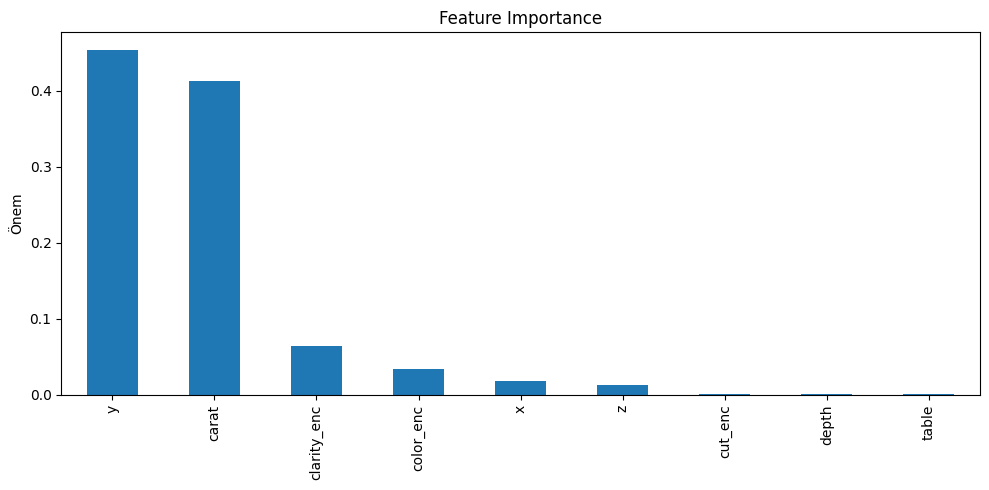

In [8]:
importances = pd.Series(model.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

print("Özellik Önem Sırası:")
print(importances.round(4))

importances.plot(kind='bar', figsize=(10, 5), title='Feature Importance')
plt.ylabel('Önem')
plt.tight_layout()
plt.show()

In [9]:
corr = df[['carat', 'x', 'y', 'z', 'price']].corr()
print(corr.round(3))

       carat      x      y      z  price
carat  1.000  0.975  0.952  0.953  0.922
x      0.975  1.000  0.975  0.971  0.884
y      0.952  0.975  1.000  0.952  0.865
z      0.953  0.971  0.952  1.000  0.861
price  0.922  0.884  0.865  0.861  1.000


In [10]:
features_v2 = ['carat', 'cut_enc', 'color_enc', 'clarity_enc', 'depth', 'table']

X2 = df[features_v2]
y2 = df['price']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

model_v2 = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model_v2.fit(X2_train, y2_train)
y2_pred = model_v2.predict(X2_test)

r2_v2   = r2_score(y2_test, y2_pred)
mae_v2  = mean_absolute_error(y2_test, y2_pred)
rmse_v2 = np.sqrt(mean_squared_error(y2_test, y2_pred))

print("=== Model v2 (x,y,z olmadan) ===")
print(f"R²   : {r2_v2:.4f}")
print(f"MAE  : ${mae_v2:.0f}")
print(f"RMSE : ${rmse_v2:.0f}")

print("\n=== Karşılaştırma ===")
print(f"R²   : {r2:.4f}  →  {r2_v2:.4f}")
print(f"MAE  : ${mae:.0f}  →  ${mae_v2:.0f}")
print(f"RMSE : ${rmse:.0f}  →  ${rmse_v2:.0f}")

=== Model v2 (x,y,z olmadan) ===
R²   : 0.9820
MAE  : $277
RMSE : $534

=== Karşılaştırma ===
R²   : 0.9823  →  0.9820
MAE  : $274  →  $277
RMSE : $530  →  $534


In [11]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(model_v2, f)

print("✅ Model kaydedildi → model.pkl")

✅ Model kaydedildi → model.pkl
